# ML Lab 01 – Data Understanding, Linear & Logistic Regression
1. Đọc dữ liệu → 2. Kiểm tra chất lượng → 3. Thống kê mô tả → 4. Heatmap
→ 5. Chuẩn hóa → 6. Linear Regression (RMSE) → 7. Logistic Regression (F1 + Confusion Matrix)

Nguyên tắc xuyên suốt: mọi bước "học" từ dữ liệu (điền thiếu, chuẩn hóa) chỉ được fit trên tập **train**,
đóng gói trong `Pipeline` để tránh rò rỉ dữ liệu (data leakage).

In [126]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, mean_squared_error
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:  # chạy trong notebook
    BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

In [127]:

def save_fig(name):
    path = os.path.join(OUTPUT_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print(f"Đã lưu hình: outputs/{name}")
    if matplotlib.get_backend().lower() == "agg":
        plt.close()
    else:
        plt.show()

## 1. Đọc dữ liệu

In [128]:
startups = pd.read_csv(os.path.join(DATA_DIR, "50_Startups.csv"))
ads = pd.read_csv(os.path.join(DATA_DIR, "Social_Network_Ads.csv"))
print("50_Startups:", startups.shape)
print(startups.head(), "\n")
print("Social_Network_Ads:", ads.shape)
print(ads.head())

50_Startups: (50, 5)
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1        NaN       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94 

Social_Network_Ads: (400, 5)
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19          19000.0          0
1  15810944    Male   35          20000.0          0
2  15668575  Female   26          43000.0          0
3  15603246  Female   27          57000.0          0
4  15804002    Male   19          76000.0          0


## 2. Kiểm tra chất lượng dữ liệu (cleaning)
- Đếm giá trị thiếu, dòng trùng.
- `User ID` chỉ là mã định danh → loại bỏ.
- **Chưa điền giá trị thiếu ở đây**: việc điền (bằng median) nằm trong Pipeline ở bước 6–7
  để median được tính từ tập train. Thống kê mô tả ở bước 3 vì thế phản ánh dữ liệu thật,
  không bị méo bởi giá trị điền vào.

In [129]:
def quality_report(df, name):
    print(f"--- {name} ---")
    report = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum()})
    print(report)
    print(f"Dòng trùng lặp: {df.duplicated().sum()}\n")


quality_report(startups, "50_Startups")
quality_report(ads, "Social_Network_Ads")

--- 50_Startups ---
                   dtype  missing
R&D Spend        float64        2
Administration   float64        3
Marketing Spend  float64        2
State                str        0
Profit           float64        0
Dòng trùng lặp: 0

--- Social_Network_Ads ---
                   dtype  missing
User ID            int64        0
Gender               str        0
Age                int64        0
EstimatedSalary  float64       17
Purchased          int64        0
Dòng trùng lặp: 0



In [130]:
startups = startups.drop_duplicates()
ads = ads.drop_duplicates().drop(columns=["User ID"])

# Số 0 trong cột chi tiêu: có thể là "không chi" hoặc dữ liệu thiếu bị ghi thành 0 → chỉ ghi nhận, không sửa
for col in ["R&D Spend", "Marketing Spend"]:
    print(f"{col}: {(startups[col] == 0).sum()} dòng bằng 0")

R&D Spend: 2 dòng bằng 0
Marketing Spend: 3 dòng bằng 0


## 3. Thống kê mô tả
- Tính trên giá trị thật (bỏ qua ô thiếu), **chưa** điền.
- Độ lệch dùng **hệ số skewness** (không phụ thuộc đơn vị đo):
  |skew| < 0.5 gần đối xứng · 0.5–1 lệch vừa · > 1 lệch mạnh.
- **Mode** chỉ có nghĩa khi có giá trị lặp lại; biến liên tục mà mọi giá trị đều khác nhau thì ghi "không có".
- Outlier theo quy tắc IQR: ngoài [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

In [131]:
def skew_label(s):
    a = abs(s)
    side = "phải" if s > 0 else "trái"
    if a < 0.5:
        return "gần đối xứng"
    return f"lệch {side} {'vừa' if a < 1 else 'mạnh'}"


def describe_numeric(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        counts = s.value_counts()
        mode = f"{counts.index[0]:,.2f} (×{counts.iloc[0]})" if counts.iloc[0] > 1 else "không có"
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        rows.append({
            "Cột": col, "N": len(s), "Thiếu": df[col].isna().sum(),
            "Mean": s.mean(), "Median": s.median(), "Mode": mode,
            "Variance": s.var(), "Std": s.std(), "Min": s.min(), "Max": s.max(),
            "IQR": iqr, "Skew": s.skew(), "Nhận xét": skew_label(s.skew()), "Outliers": outliers,
        })
    return pd.DataFrame(rows).set_index("Cột")


stats_startups = describe_numeric(startups, ["R&D Spend", "Administration", "Marketing Spend", "Profit"])
stats_ads = describe_numeric(ads, ["Age", "EstimatedSalary"])
fmt = lambda v: f"{v:,.2f}"
print(stats_startups.to_string(float_format=fmt), "\n")
print(stats_ads.to_string(float_format=fmt), "\n")

print("Biến phân loại:")
print(startups["State"].value_counts().to_string(), "\n")
print(ads["Gender"].value_counts().to_string(), "\n")
print(f"Tỉ lệ Purchased = 1: {ads['Purchased'].mean():.1%}")

with open(os.path.join(OUTPUT_DIR, "statistics.md"), "w", encoding="utf-8") as f:
    f.write("# Thống kê mô tả (trên dữ liệu gốc, bỏ qua ô thiếu)\n\n")
    f.write("## 50_Startups\n\n" + stats_startups.to_markdown(floatfmt=",.2f") + "\n\n")
    f.write("## Social_Network_Ads\n\n" + stats_ads.to_markdown(floatfmt=",.2f") + "\n\n")
    f.write("## Biến phân loại\n\n" + startups["State"].value_counts().to_markdown() + "\n\n")
    f.write(ads["Gender"].value_counts().to_markdown() + "\n\n")
    f.write(f"Tỉ lệ `Purchased = 1`: **{ads['Purchased'].mean():.1%}**\n")

                  N  Thiếu       Mean     Median       Mode          Variance        Std       Min        Max        IQR  Skew       Nhận xét  Outliers
Cột                                                                                                                                                    
R&D Spend        48      2  72,084.88  73,051.08  0.00 (×2)  2,023,615,779.19  44,984.62      0.00 165,349.20  64,874.78  0.12   gần đối xứng         0
Administration   47      3 123,179.85 124,153.04   không có    751,575,466.77  27,414.88 51,283.14 182,645.56  38,088.72 -0.56  lệch trái vừa         0
Marketing Spend  48      2 214,887.37 221,897.88  0.00 (×3) 14,918,723,808.82 122,142.23      0.00 471,784.10 168,166.02 -0.08   gần đối xứng         0
Profit           50      0 112,012.64 107,978.19   không có  1,624,588,173.41  40,306.18 14,681.40 192,261.83  49,627.07  0.02   gần đối xứng         1 

                   N  Thiếu      Mean    Median             Mode         Variance     

Đã lưu hình: outputs/distribution_startups.png


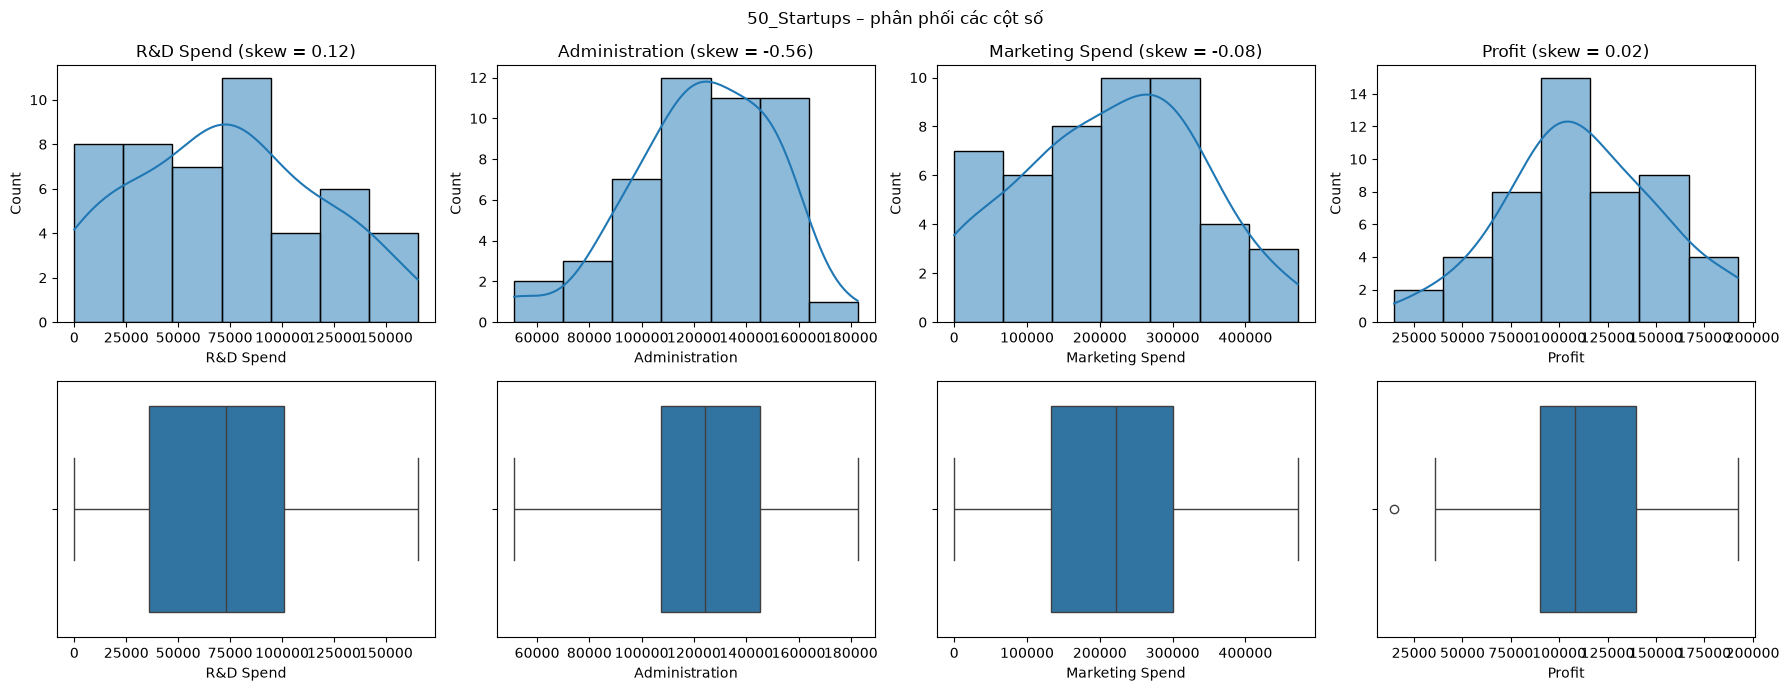

Đã lưu hình: outputs/distribution_ads.png


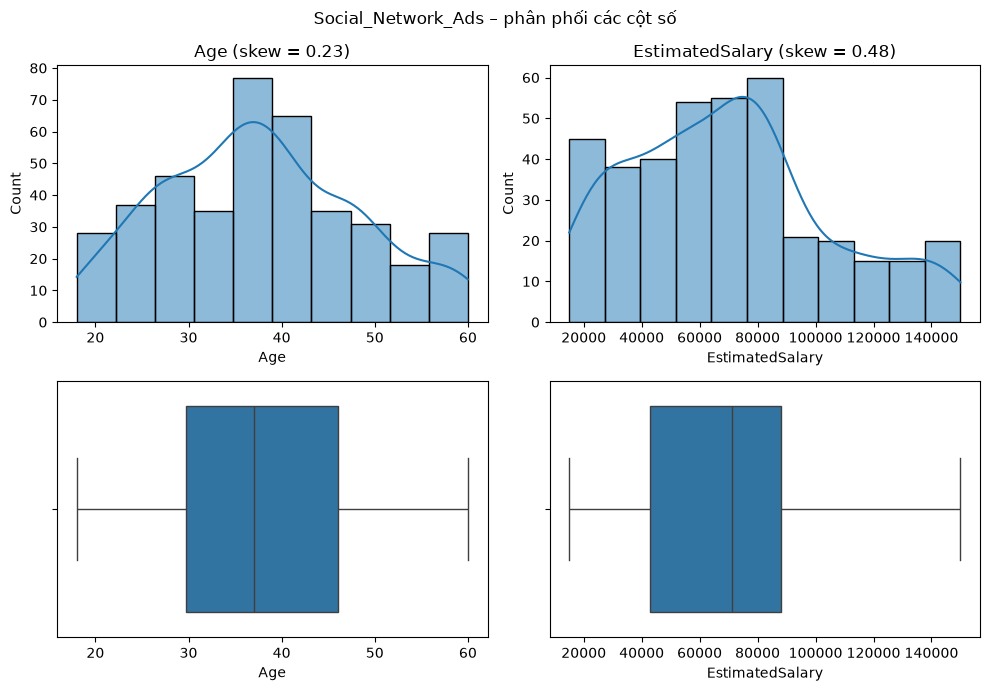

In [132]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(["R&D Spend", "Administration", "Marketing Spend", "Profit"]):
    sns.histplot(startups[col].dropna(), kde=True, ax=axes[0, i])
    sns.boxplot(x=startups[col].dropna(), ax=axes[1, i])
    axes[0, i].set_title(f"{col} (skew = {startups[col].skew():.2f})")
plt.suptitle("50_Startups – phân phối các cột số")
plt.tight_layout()
save_fig("distribution_startups.png")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i, col in enumerate(["Age", "EstimatedSalary"]):
    sns.histplot(ads[col].dropna(), kde=True, ax=axes[0, i])
    sns.boxplot(x=ads[col].dropna(), ax=axes[1, i])
    axes[0, i].set_title(f"{col} (skew = {ads[col].skew():.2f})")
plt.suptitle("Social_Network_Ads – phân phối các cột số")
plt.tight_layout()
save_fig("distribution_ads.png")

## 4. Heatmap tương quan (không đưa cột target vào)

Đã lưu hình: outputs/heatmap.png


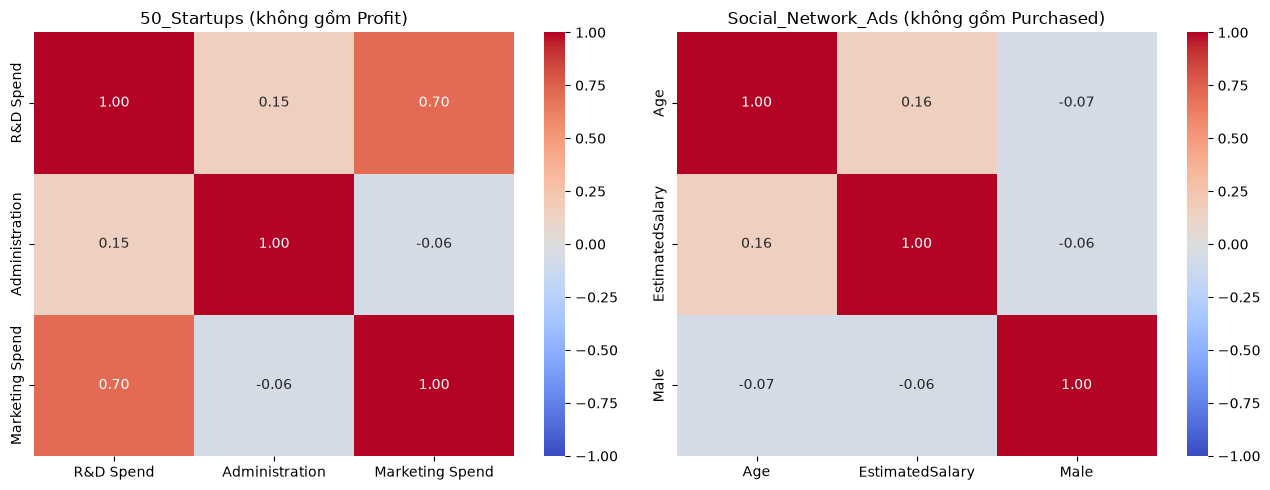

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(startups[["R&D Spend", "Administration", "Marketing Spend"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("50_Startups (không gồm Profit)")
ads_corr = ads[["Age", "EstimatedSalary"]].assign(Male=(ads["Gender"] == "Male").astype(int)).corr()
sns.heatmap(ads_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Social_Network_Ads (không gồm Purchased)")
plt.tight_layout()
save_fig("heatmap.png")

## 5. Chuẩn hóa dữ liệu
- Chỉ chuẩn hóa **feature**, không chuẩn hóa **target**.
- Chia train/test **trước**, fit scaler trên train rồi mới transform test.
- Minh họa trên `Age`, `EstimatedSalary` (hai cột chênh nhau ~1 000 lần về thang đo).

Train – trước chuẩn hóa:
                      mean       std      min       max
Age                 37.16     10.67     18.0      60.0
EstimatedSalary  71098.04  35137.44  15000.0  150000.0

Train – sau chuẩn hóa (mean ≈ 0, std ≈ 1):
                  mean  std   min   max
Age               0.0  1.0 -1.80  2.14
EstimatedSalary   0.0  1.0 -1.64  2.30

Test – sau chuẩn hóa (dùng mean/std của train nên không đúng 0/1 tuyệt đối):
                  mean   std
Age              0.23  0.89
EstimatedSalary -0.16  0.88
Đã lưu hình: outputs/normalization.png


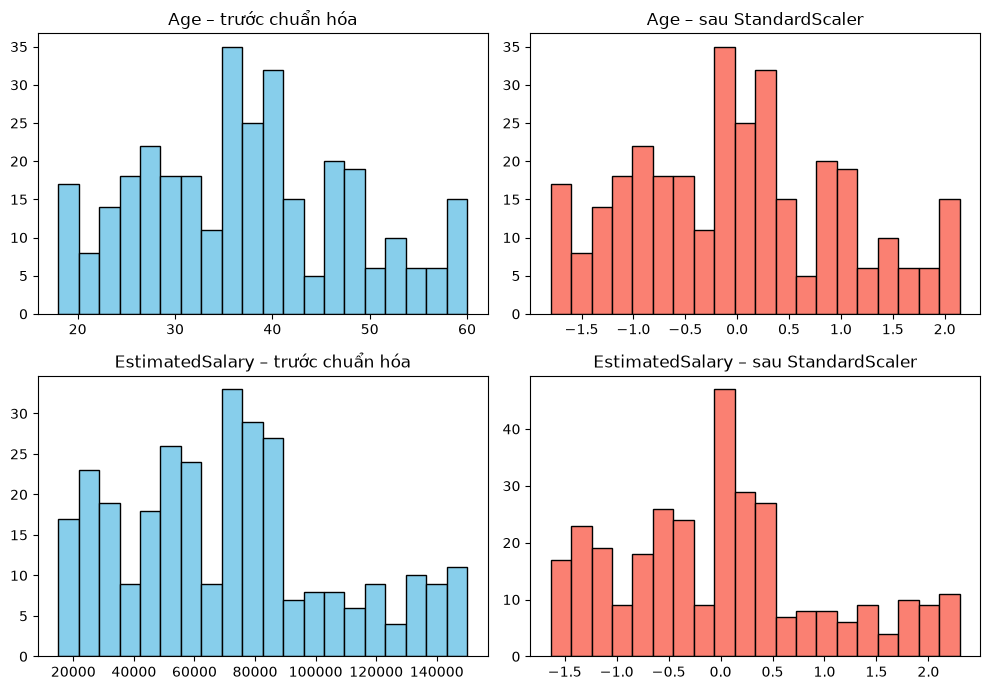

In [134]:
X_ads = ads[["Age", "EstimatedSalary"]]
y_ads = ads["Purchased"]
X_tr_ads, X_te_ads, y_tr_ads, y_te_ads = train_test_split(
    X_ads, y_ads, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ads)

demo = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
X_tr_scaled = pd.DataFrame(demo.fit_transform(X_tr_ads), columns=X_ads.columns)
X_te_scaled = pd.DataFrame(demo.transform(X_te_ads), columns=X_ads.columns)

print("Train – trước chuẩn hóa:\n", X_tr_ads.describe().T[["mean", "std", "min", "max"]].round(2))
print("\nTrain – sau chuẩn hóa (mean ≈ 0, std ≈ 1):\n", X_tr_scaled.describe().T[["mean", "std", "min", "max"]].round(2))
print("\nTest – sau chuẩn hóa (dùng mean/std của train nên không đúng 0/1 tuyệt đối):\n",
      X_te_scaled.describe().T[["mean", "std"]].round(2))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i, col in enumerate(X_ads.columns):
    axes[i, 0].hist(X_tr_ads[col].dropna(), bins=20, color="skyblue", edgecolor="black")
    axes[i, 0].set_title(f"{col} – trước chuẩn hóa")
    axes[i, 1].hist(X_tr_scaled[col], bins=20, color="salmon", edgecolor="black")
    axes[i, 1].set_title(f"{col} – sau StandardScaler")
plt.tight_layout()
save_fig("normalization.png")

## 6. Linear Regression – 50_Startups (target: Profit)
- Feature: 3 cột chi tiêu. `State` bị loại vì cross-validation cho thấy thêm vào làm RMSE **tăng**.
- Pipeline: điền thiếu bằng median → StandardScaler → LinearRegression.
  (Với OLS, chuẩn hóa không đổi dự đoán, chỉ giúp so sánh độ lớn hệ số.)

So sánh bộ feature bằng 5-fold CV trên tập train (RMSE, càng thấp càng tốt):
  ['R&D Spend']                                                    14,556 ± 8,315
  ['R&D Spend', 'Administration', 'Marketing Spend']               14,756 ± 6,460
  ['R&D Spend', 'Administration', 'Marketing Spend', 'State']      16,372 ± 5,711

RMSE trên tập test: 11,943.48
Hệ số (trên feature đã chuẩn hóa – so sánh được độ quan trọng):
R&D Spend          31186.25
Administration      2046.26
Marketing Spend    11230.15
Đã lưu hình: outputs/linear_regression.png


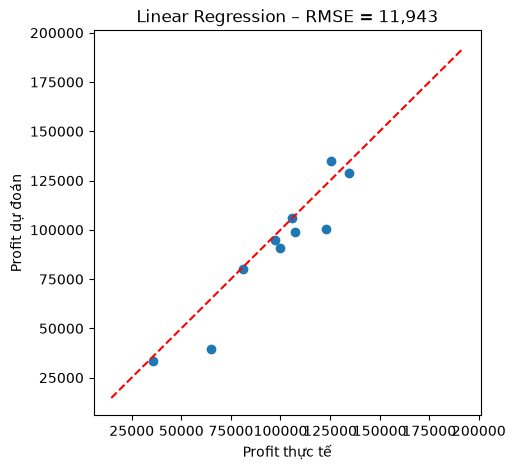

In [135]:
SPEND_COLS = ["R&D Spend", "Administration", "Marketing Spend"]
X_st = startups[SPEND_COLS + ["State"]]
y_st = startups["Profit"]
X_tr_st, X_te_st, y_tr_st, y_te_st = train_test_split(X_st, y_st, test_size=0.2, random_state=RANDOM_STATE)


def make_linear(cols):
    num = [c for c in cols if c != "State"]
    steps = [("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num)]
    if "State" in cols:
        steps.append(("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["State"]))
    return Pipeline([("prep", ColumnTransformer(steps)), ("model", LinearRegression())])


kfold = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print("So sánh bộ feature bằng 5-fold CV trên tập train (RMSE, càng thấp càng tốt):")
for cols in (["R&D Spend"], SPEND_COLS, SPEND_COLS + ["State"]):
    scores = -cross_val_score(make_linear(cols), X_tr_st[cols], y_tr_st, cv=kfold,
                              scoring="neg_root_mean_squared_error")
    print(f"  {str(cols):60s} {scores.mean():>10,.0f} ± {scores.std():,.0f}")

lin_model = make_linear(SPEND_COLS).fit(X_tr_st[SPEND_COLS], y_tr_st)
y_pred_st = lin_model.predict(X_te_st[SPEND_COLS])
rmse = np.sqrt(mean_squared_error(y_te_st, y_pred_st))
coefs = pd.Series(lin_model.named_steps["model"].coef_, index=SPEND_COLS, name="Hệ số")
print(f"\nRMSE trên tập test: {rmse:,.2f}")
print("Hệ số (trên feature đã chuẩn hóa – so sánh được độ quan trọng):")
print(coefs.round(2).to_string())

plt.figure(figsize=(5, 5))
plt.scatter(y_te_st, y_pred_st)
lims = [y_st.min(), y_st.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Profit thực tế")
plt.ylabel("Profit dự đoán")
plt.title(f"Linear Regression – RMSE = {rmse:,.0f}")
save_fig("linear_regression.png")

## 7. Logistic Regression – Social_Network_Ads (target: Purchased)
- Feature: `Age`, `EstimatedSalary`. `Gender` không cải thiện F1 khi cross-validation.
- Chia **stratified** để tỉ lệ mua/không mua giống nhau ở train và test.
- Pipeline: điền thiếu bằng median → StandardScaler → LogisticRegression.

5-fold CV F1 trên train: 0.7589 ± 0.0727
F1-Score trên tập test: 0.7451
Confusion Matrix [[TN, FP], [FN, TP]]:
 [[48  3]
 [10 19]]
               precision    recall  f1-score   support

Không mua (0)       0.83      0.94      0.88        51
      Mua (1)       0.86      0.66      0.75        29

     accuracy                           0.84        80
    macro avg       0.85      0.80      0.81        80
 weighted avg       0.84      0.84      0.83        80

Đã lưu hình: outputs/logistic_confusion_matrix.png


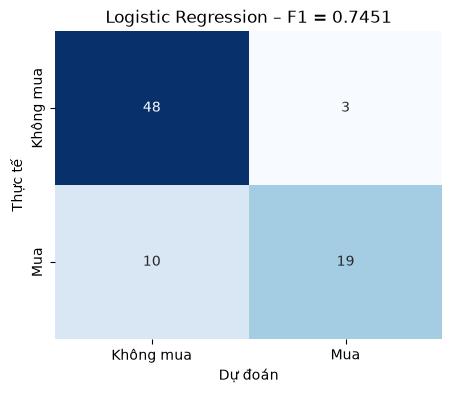

In [136]:
skfold = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
log_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", LogisticRegression()),
])
cv_f1 = cross_val_score(log_model, X_tr_ads, y_tr_ads, cv=skfold, scoring="f1")
print(f"5-fold CV F1 trên train: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

log_model.fit(X_tr_ads, y_tr_ads)
y_pred_ads = log_model.predict(X_te_ads)
f1 = f1_score(y_te_ads, y_pred_ads)
cm = confusion_matrix(y_te_ads, y_pred_ads)
print(f"F1-Score trên tập test: {f1:.4f}")
print("Confusion Matrix [[TN, FP], [FN, TP]]:\n", cm)
print(classification_report(y_te_ads, y_pred_ads, target_names=["Không mua (0)", "Mua (1)"]))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Không mua", "Mua"], yticklabels=["Không mua", "Mua"])
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Logistic Regression – F1 = {f1:.4f}")
save_fig("logistic_confusion_matrix.png")

In [137]:
with open(os.path.join(OUTPUT_DIR, "results.md"), "w", encoding="utf-8") as f:
    f.write("# Kết quả ML Lab 01\n\n")
    f.write("| Bài | Chỉ số | Giá trị |\n|---|---|---|\n")
    f.write(f"| Linear Regression | RMSE (test) | {rmse:,.2f} |\n")
    f.write(f"| Logistic Regression | F1 (test) | {f1:.4f} |\n")
    f.write(f"| Logistic Regression | F1 (5-fold CV trên train) | {cv_f1.mean():.4f} ± {cv_f1.std():.4f} |\n\n")
    f.write("Confusion Matrix Logistic Regression `[[TN, FP], [FN, TP]]`:\n\n```\n" + str(cm) + "\n```\n\n")
    f.write("Hệ số Linear Regression (feature đã chuẩn hóa):\n\n" + coefs.to_markdown(floatfmt=",.2f") + "\n")
print("Đã lưu outputs/results.md")

Đã lưu outputs/results.md
